# Lab #6: Sunspots
### Farhan Ariff bin Halis Azhan
### Collaborators
* Name
* Name

## Goal and Introduction
The sun solar cycle occurs every 11 years and it rotate every 27 days, although it can get as fast as 25 days.  
The goal of this lab is to perform Short Term Fourier Transformation manually on the dataset, by taking window/subset of the dataset to perform fft on.

## Data
The dataset that will be used in this lab is solar_flux.txt, which containted the time it records the value of the solar radio flux at wavelength of 10.7cm.  
The unit for the value will be in $W/m^{2}/Hz$.

----

## Approach and Results
Import important libraries for the lab.

In [159]:
# Import critical libraries:
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from dateutil.relativedelta import relativedelta
from scipy.ndimage import uniform_filter1d

### Question 1
First, we will start by reading the input file, which is solar_flux.txt.

In [160]:
def read_file(filename):
    # read files using genfromtxt function
    # we will skip the first 70 header, and only use column from third to seventh columns.
    tconvert = lambda x: dt.datetime.strptime(str(x), '%Y-%m-%d') 
    
    data = np.genfromtxt(filename, converters= {0:tconvert},
                         skip_header=16, usecols= (0,2),
                         dtype=None, encoding = 'utf-8', names=True)
    return data

In [161]:
data = read_file('./solar_flux.txt')
# print(data)
# print(data.dtype.names)

In [162]:
# assign the data columns' into variable for easier access
dataTime = data['yyyyMMdd']
dataValue = data["value"]

Now we want to calculate the 3-year running mean of the data, then plot it over the original datasets.

Text(0, 0.5, 'Solar radio flux $W/m^2/Hz$')

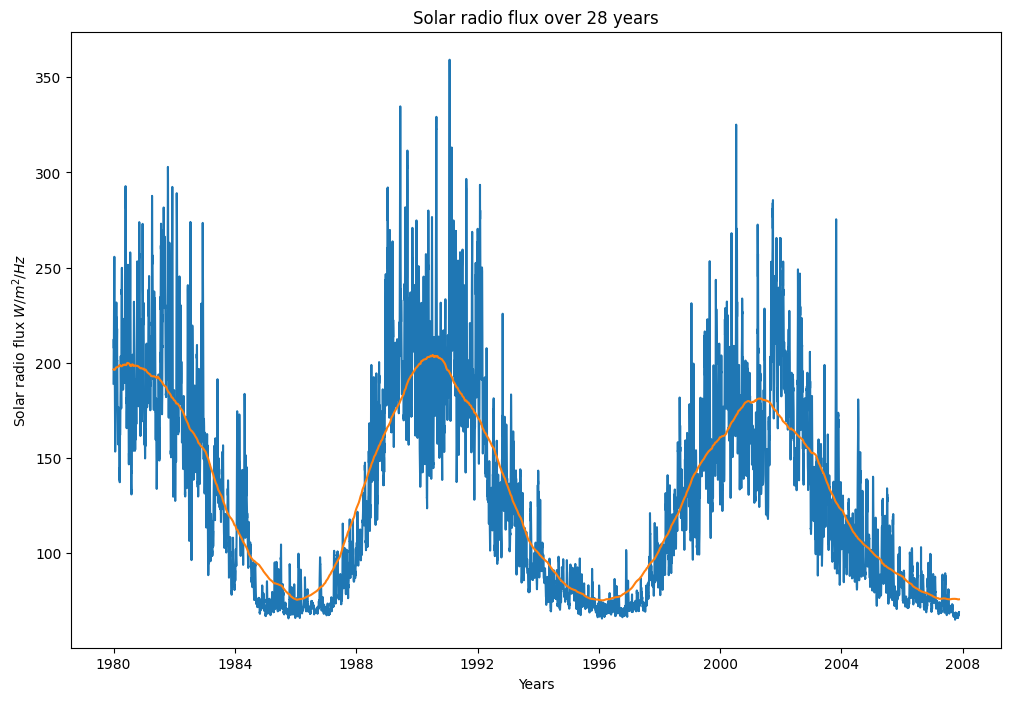

In [163]:
data_filter = uniform_filter1d(dataValue, size = 1095)
# print(data_filter)
# Make a figure variable
fig = plt.figure(figsize=(12,8))
ax = fig.subplots(1,1)

# Plot the date againt filter over the original data
ax.plot(dataTime, dataValue, label = 'original dateasets')
ax.plot(dataTime, data_filter, label = "3-year running mean")

# put title, xlabel and ylabel
ax.set_title(f'Solar radio flux over 28 years')
ax.set_xlabel(f"Years")
ax.set_ylabel(f"Solar radio flux $W/m^{2}/Hz$")


From the plot above, we can approximate the the years of solar maximums and minimums.  
Solar Maximums occur approximately on 1980, 1990,2001, while the solar minimums occur appriximately on 1986, 1996 , and 2007.  
Based on readings, solar cycle happens every 11 years, and solar maximum transition to solar minimum and vice versa takes 6 years, and these approximations seems acceptable to the readings.  

### Question 2
Now we want to see the datasets in perspective of frequency domain. We will do this three times.  

The first time, we will use the the whole dataset and use timestep value so that the frequency is cycle per year  
and plot the entire power spectrum.  

The second time, we will zoom into the plot we made above to frequency between 0.05 to 0.2 cycles per year.  
Then we will attempt to find the period that correspond to the maximum power, and see its physical significance.

The third time, we will now insted use timestep value so that the frequency is cycle per day, and zoom in to the  
frequency between 0.025 to 0.05 cycles/day.  
Then we will attempt to find the period that correspond to the maximum power, and see its physical significance.

As mentioned above, we will start by plotting the power spectrum for the whole datasets with frequency of cycle per year.

In [164]:
from scipy.fftpack import fft, fftfreq

# the time step for cycles per year
dtYear = 1.0/365.0

# length of time series
N = dataValue.size 

# print(N/dtYear)

# get fast fourier transform of the dataset
data_ft = fft(dataValue) / N

# get frequency associated with the FT
freqsfft = fftfreq(N, dtYear)

Text(0, 0.5, 'Sola flux squared')

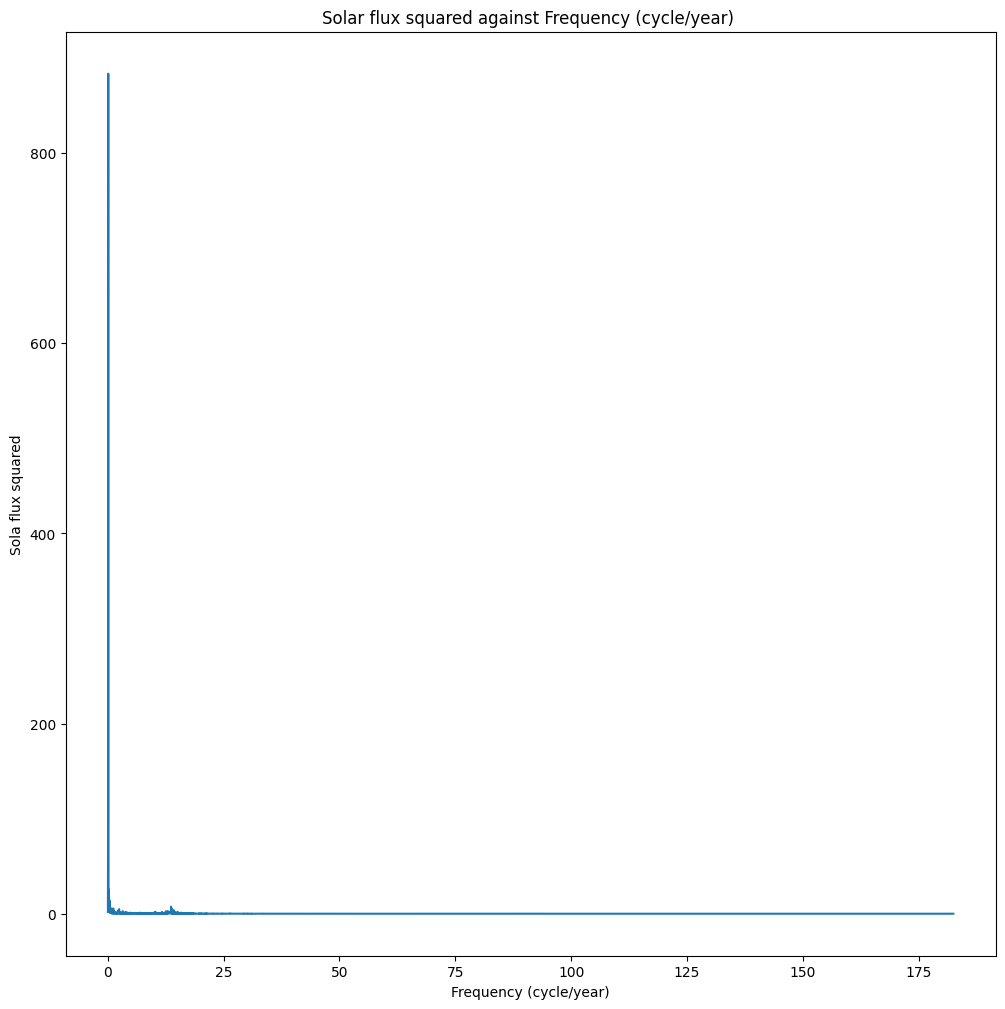

In [165]:
# Make a figure of the power spectrum for flux against frequency
fig = plt.figure(figsize=(12, 12))
axe = plt.subplot(111)

# Plot the power against frequency
axe.plot(freqsfft[1:N//2], np.abs(data_ft[1:N//2]) ** 2)
# axe.plot(freqsfft[1:N//2], np.abs(data_ft[1:N//2]), 'o')

# give title, xlabel, ylabel into axis 
axe.set_title(f'Solar flux squared against Frequency (cycle/year) ')
axe.set_xlabel(f'Frequency (cycle/year)')
axe.set_ylabel(f'Sola flux squared')

The plot above is the power spectrum for the whole dataset.  

Now we will zoom in into the above plot for frequency of between 0.05 to 0.2, by using boolean indexing to only get the frequency range that we wanted.

In [166]:
# only get the frequency between 0.05 to 0.2
freqsfftzoomy = (freqsfft > 0.05) & (freqsfft < 0.2)
# filter only the fft corresponding to the frequency
datazoomy = data_ft[freqsfftzoomy]

In [167]:
# print(datazoomy.size)
# print(abs(datazoomy))

Text(0, 0.5, 'Solar flux squared')

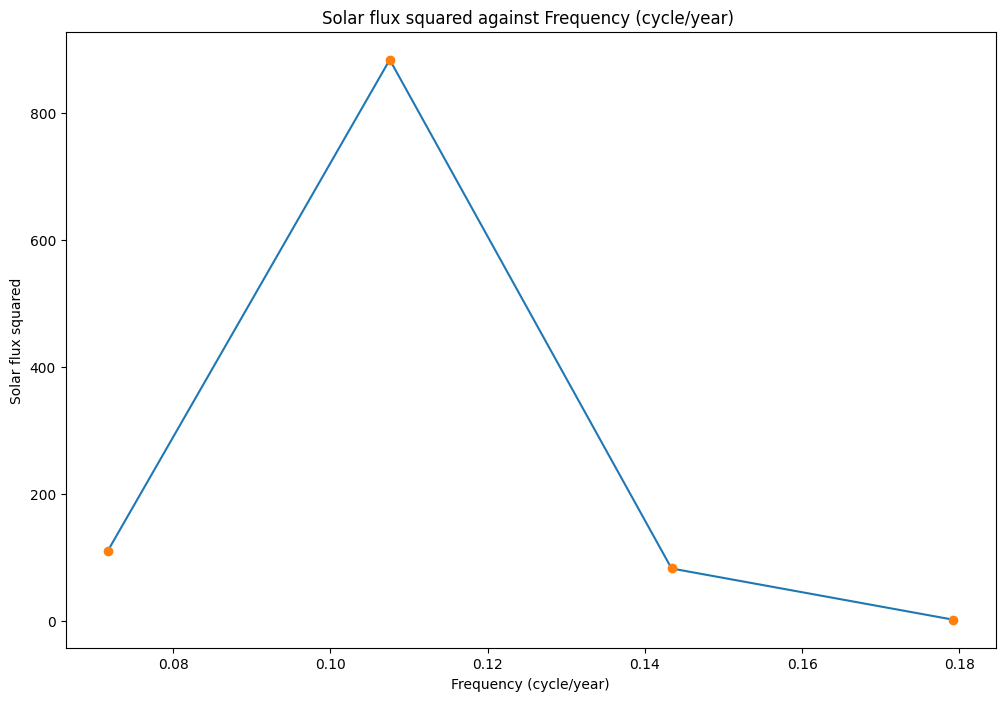

In [168]:
# Make a figure of the transformation against the frequency
fig = plt.figure(figsize=(12, 8))
axe2 = plt.subplot(111)

absZoom = abs(datazoomy) ** 2

# Plot the power spectrum for frequency between 0.05 to 0.02
axe2.plot(freqsfft[freqsfftzoomy], absZoom)
axe2.plot(freqsfft[freqsfftzoomy], absZoom, 'o')

freqsfftyear = freqsfft[freqsfftzoomy]

# give title, xlabel, ylabel into axis 
axe2.set_title(f'Solar flux squared against Frequency (cycle/year) ')
axe2.set_xlabel(f'Frequency (cycle/year)')
axe2.set_ylabel(f'Solar flux squared')

In [169]:
# The index for the largest power
largest_pow_index = np.argmax(absZoom)
print(f"The index for the largest amplitude is : {largest_pow_index}")
print(f"The frequency for the largest power between 0.05 to 0.20 Hz is {freqsfftyear[largest_pow_index]}")
print(f"The corresponding period for the frequency is {1.0/freqsfftyear[largest_pow_index]}")

The index for the largest amplitude is : 1
The frequency for the largest power between 0.05 to 0.20 Hz is 0.10754272245138478
The corresponding period for the frequency is 9.298630136986302


The physical significance of the period is that the largest power occur when the period is 9 years per cycle.  
This is significance as the solar cycle takes 11 years, which are near the period mentioned above.

Now we will want to plot the whole dataset again, but this time around with frequency of cycle per day. The only changes to below code would the our timestep.
Instead of using dtYear for time step of a year, we use dtDay to indicate time step of a day, essentially changing it from cycle/year to cycle/day.

In [170]:
# the time step is a cycles per day
dtDay = 1.0/1.0

# print(N/dtDay)
# get fast fourier transform of the detrend
data_ft = fft(dataValue) / N

# get frequency associated with the FT
freqsfft = fftfreq(N, dtDay)

The plot below used the whole frequency to plot it.

Text(0, 0.5, 'Solar flux squared')

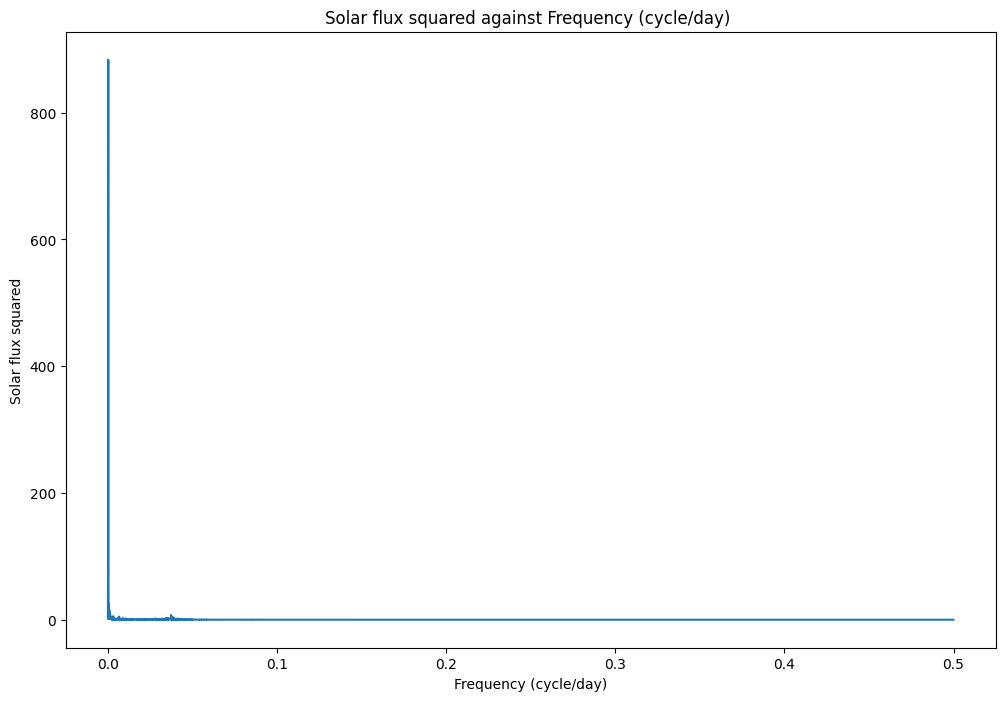

In [171]:
# Make a figure of the transformation against the frequency
fig = plt.figure(figsize=(12, 8))
axe = plt.subplot(111)

axe.plot(freqsfft[1:N//2], np.abs(data_ft[1:N//2]) ** 2)

# give title, xlabel, ylabel into axis 
axe.set_title(f'Solar flux squared against Frequency (cycle/day) ')
axe.set_xlabel(f'Frequency (cycle/day)')
axe.set_ylabel(f'Solar flux squared')

The below plot used only the frequency range that we wanted (from 0.025 to 0.05)

In [172]:
# only get the frequency between 0.025 to 0.05
freqsfftzoomyday = (freqsfft > 0.025) & (freqsfft < 0.05)
# filter only the fft corresponding to the frequency
datazoomyday = data_ft[freqsfftzoomyday]

Text(0, 0.5, 'Solar flux squared')

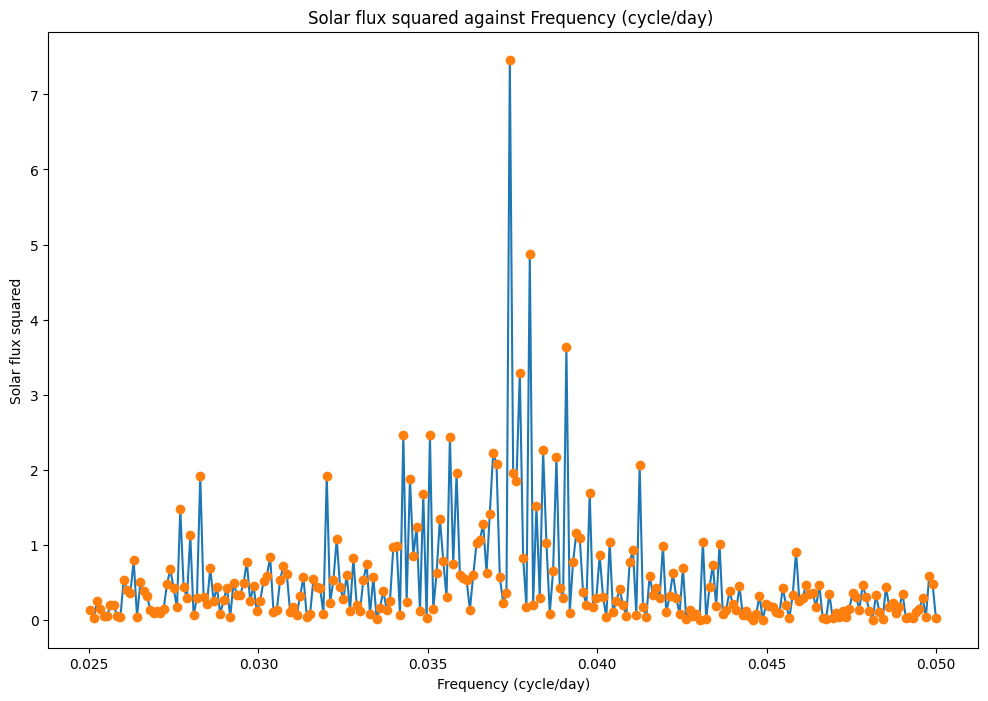

In [173]:
# Make a figure of the transformation against the frequency
fig = plt.figure(figsize=(12, 8))
axe2 = plt.subplot(111)

absZoomday = abs(datazoomyday) ** 2

axe2.plot(freqsfft[freqsfftzoomyday], absZoomday)
axe2.plot(freqsfft[freqsfftzoomyday], absZoomday, 'o')

freqsfftzoomday = freqsfft[freqsfftzoomyday]

# give title, xlabel, ylabel into axis 
axe2.set_title(f'Solar flux squared against Frequency (cycle/day) ')
axe2.set_xlabel(f'Frequency (cycle/day)')
axe2.set_ylabel(f'Solar flux squared')

In [174]:
# The index for the largest power
largest_pow_index = np.argmax(absZoomday)
print(absZoomday[largest_pow_index])
print(f"The index for the largest amplitude is : {largest_pow_index}")
print(f"The frequency for the largest power between 0.05 to 0.20 Hz is {freqsfftzoomday[largest_pow_index]}")
print(f"The corresponding period for the frequency is {1.0/freqsfftzoomday[largest_pow_index]}")

7.462478929602268
The index for the largest amplitude is : 126
The frequency for the largest power between 0.05 to 0.20 Hz is 0.03741897466116677
The corresponding period for the frequency is 26.724409448818896


The physical significance of the period is that the largest power occur when the period is approximately 27 days per cycle.  
This is significance as the sun takes approximately 27 days to rotate, although it can be faster up to 25 days.

### Question 3
In previous section, we perform fft on the whole datasets. 
Now, we want to use only the first 5 years of the time series in our fft.
After doing that, we will want to plot the power spectrum over the range 0.025 to 0.05 cycles/day. 
To do this, we will use logical indexing to the desired range mentioned above.
Like previous section, we will want to find the peak power, and from that the corresponding frequency and then the period.

In [175]:
years5 = data["yyyyMMdd"][0] + relativedelta(years = 5)
data5years = data[data["yyyyMMdd"] <= years5]["value"]

In [176]:
# the time step is a cycles per day
dtDay = 1.0/1.0
# length of time series, we need to reassign because the size difference
N = data5years.size 
# get fast fourier transform of the detrend
data_ft = fft(data5years) / N

# get frequency associated with the FT
freqsfft = fftfreq(N, dtDay)

Text(0, 0.5, 'Solar flux squared')

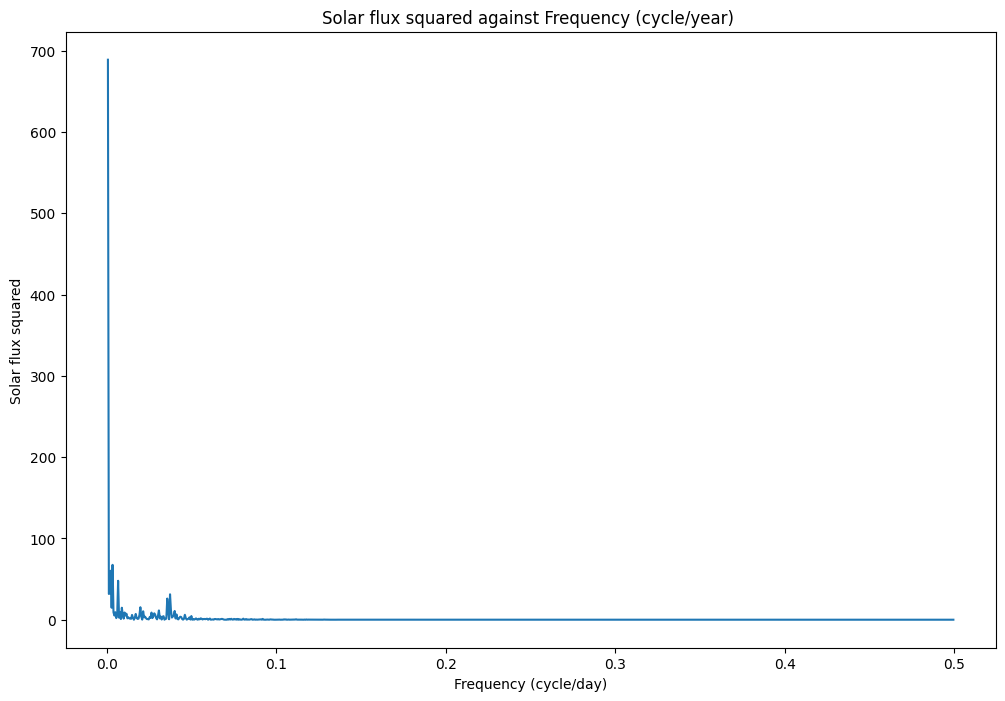

In [177]:
# Make a figure of the transformation against the frequency
fig = plt.figure(figsize=(12, 8))
axe3 = plt.subplot(111)


axe3.plot(freqsfft[1:N//2], np.abs(data_ft[1:N//2]) ** 2)
# axe.plot(freqsfft[1:N//2], np.abs(data_ft[1:N//2]) ** 2, 'o')

# give title, xlabel, ylabel into axis 
axe3.set_title(f'Solar flux squared against Frequency (cycle/year) ')
axe3.set_xlabel(f'Frequency (cycle/day)')
axe3.set_ylabel(f'Solar flux squared')

In [178]:
# only get the frequency between 0.05 to 0.2
freqsfftzoomyday = (freqsfft > 0.025) & (freqsfft < 0.05)
# filter only the fft corresponding to the frequency
datazoomyday = data_ft[freqsfftzoomyday]

Text(0, 0.5, 'Solar flux squared')

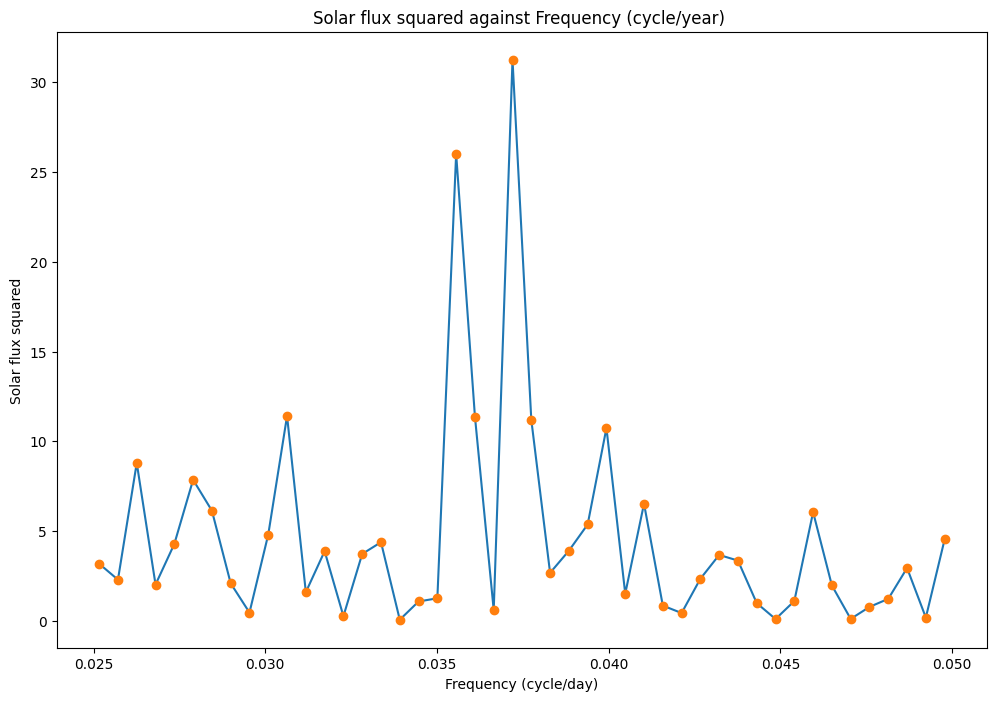

In [179]:
# Make a figure of the transformation against the frequency
fig = plt.figure(figsize=(12, 8))
axe2 = plt.subplot(111)
absZoomday = abs(datazoomyday) ** 2

axe2.plot(freqsfft[freqsfftzoomyday], absZoomday)
axe2.plot(freqsfft[freqsfftzoomyday], absZoomday, 'o')
freqsfftzoom = freqsfft[freqsfftzoomyday]
# give title, xlabel, ylabel into axis 
axe2.set_title(f'Solar flux squared against Frequency (cycle/year) ')
axe2.set_xlabel(f'Frequency (cycle/day)')
axe2.set_ylabel(f'Solar flux squared')

In [180]:
# The index for the largest power
largest_pow_index = np.argmax(absZoomday)
print(f"The index for the largest amplitude is : {largest_pow_index}")
print(f"The frequency for the largest power between 0.05 to 0.20 Hz is {freqsfftzoom[largest_pow_index]}")
print(f"The corresponding period for the frequency is {1.0/freqsfftzoom[largest_pow_index]}")

The index for the largest amplitude is : 22
The frequency for the largest power between 0.05 to 0.20 Hz is 0.037199124726477024
The corresponding period for the frequency is 26.88235294117647


Using shortened subset of data will increase the frequency resolution for the acquired spectrum (which means it will be eaiser to understand),  
although at the cost of decreasing the highest frequency it can resolved.   
Seeing that the sampling frequency is 1.0 day, its highest resolvable frequency will be  1.0/2, which is 0.5 (proven from the full plot above).

### Question 4
Continuing from the above section, we will now attempt to find the period of the time series with subset of 5 years and offset of 10 days increment.
Like previous section, we will find the frequency corresponding to the highest power for frequency between 0.025 and 0.05, and record its period.
After that, we will plot the periods we recorded against the center of each 5-year window we used for the fft.
The code below was acquired from the pdf provided.

In [181]:
def find_period(subset_fft, subset):
    '''
    Find the corresponding period to the subset of the time series
    Return corresponding period of the highest power.
    '''
    subset_freq = fftfreq(subset.size, 1.0)
    subset_zoom_logical = (subset_freq >= 0.025) & (subset_freq <= 0.05) 
    # print(subset_zoom_logical)
    subset_pow = abs(subset_fft[subset_zoom_logical]) ** 2
    # print(subset_pow)
    largest_pow_index = np.argmax(subset_pow)
    subset_freq_zoom = subset_freq[subset_zoom_logical]
    correspond_freq = subset_freq_zoom[largest_pow_index]
    return 1.0/correspond_freq

In [182]:
from datetime import timedelta

# set up the total range of times
start, stop = dataTime[0], dataTime[-1]

# Containers for data calcualted over loop
series_data = [] # record data in loop 
series_time = [] # record the time center of each windowed FFt

# size of our window
window_size = timedelta(days = 365)
#  and how far advance for each loop
offset = timedelta(days = 10)

while start + window_size < stop:
    # the dates to use for current FFT
    time_span = start + window_size

    # Grab the subset of data we want to explore using logical indexing.    
    locations = (dataTime >= start) & (dataTime < time_span)
    subset = dataValue[locations]
    
    ### fill in FFT calculation here
    subset_fft = fft(subset)
    correspond_period = find_period(subset_fft, subset)

    # Record an important value that we wanted
    series_data.append(correspond_period)
    
    # mid-point of date range (to be used as x-axis in final plot)
    series_time.append(start + window_size/2)

    # move forward 10 days for the next loop
    start += offset
    

Text(0, 0.5, 'Period (days per cycle).')

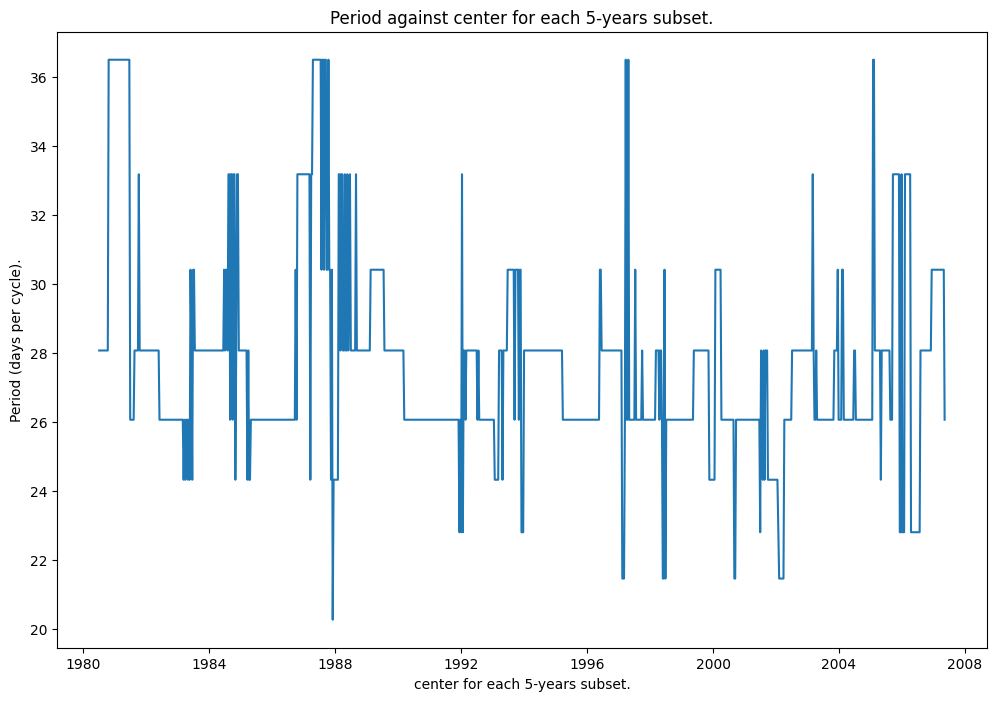

In [183]:
# Make a figure of the period against the the center date for subset 5 years with offset of 10 days incremented.
fig = plt.figure(figsize=(12, 8))
axef = plt.subplot(111)
axef.plot(series_time, series_data)
# give title, xlabel, ylabel into axis 
axef.set_title(f'Period against center for each 5-years subset.')
axef.set_xlabel(f'center for each 5-years subset.')
axef.set_ylabel(f'Period (days per cycle).')

As we can see, the dominant frequency change over the time series.
The dominant frequency change because in solar cycle, it takes 11-years for full cycle. In these 11 years, 6 years will be spent to transition from solar maximum to solar minimum or vice versa. Which means, in these 11 years to 6 years, the 
sun activity might increase or decrease, which might explain the changing of dominant frequency over the entire time series above.

## Conclusions
The solar cycle takes 11 years, and it rotates every 27 days. By using fft and zooming in to the data (by using logical indexing), we can see these kind of behavior that otherwise cannot be seen because of the noise.  
We also have learnt that fft from subset of time series (windowed datasets, shortened dataset) will have higher frequency resolution, although the highest resolvable frequency it can do will decrease (seen from question 3).  
These things are note worth taken, as signal analysis of shortened datasets are different to process than signal analysis of full datasets.
From question 4, we can see that the highest frequency changes over time, as not only sun activity changes every 6 years or 11 years (depending if we looking at transition from solar maximum to solar minimum minimum or vice versa, or full cycle), 
but sun rotation also changes with these solar cycle.

## References
List any references used